In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import sys

data_dir = Path("../data/csv")
sys.path.append("../src")

from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG
set_project_style()

In [2]:
# Initial exploration: structure of the files generated by Synthea
# Load just a preview of the files rows and columns

files = ["patients.csv", "conditions.csv", "observations.csv",
         "medications.csv", "encounters.csv"]

for f in files:
    path = data_dir / f
    preview = pd.read_csv(path, nrows=5)
    print(f"--- {f} ---")
    print("Colonne:", list(preview.columns))
    print(preview.head(2))
    print()

--- patients.csv ---
Colonne: ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']
                                     Id   BIRTHDATE  DEATHDATE          SSN  \
0  7c9e3c55-f225-5b68-ee2f-dab71e12772c  2023-01-14        NaN  999-39-2522   
1  720fe4ff-be67-e0d7-ff15-d5fee26722a6  1999-10-06        NaN  999-28-5295   

     DRIVERS    PASSPORT PREFIX      FIRST      MIDDLE        LAST  ...  \
0        NaN         NaN    NaN  Rafael239  Ricardo560  Hurtado459  ...   
1  S99918885  X15139376X    Ms.  Paulita78   Ileana390   Torphy630  ...   

           CITY          STATE            COUNTY     FIPS   ZIP        LAT  \
0        Revere  Massachusetts    Suffolk County  25025.0  2151  42.444413   
1  Southborough  Massachusetts  Worcester County   

In [3]:
# [Step 1]: identify the Type 2 Diabetes cohort from conditions.csv

# Load just the 3 columns needed to reduces memory usage
conditions = pd.read_csv(
    data_dir / "conditions.csv",
    usecols=["PATIENT", "CODE", "DESCRIPTION"]
)

# SNOMED-CT code for Type 2 Diabetes Mellitus (see protocol, Section 1)
T2D_CODE = 44054006

t2d_patients = conditions.loc[conditions["CODE"] == T2D_CODE, "PATIENT"].unique()

print(f"Patients with a Type 2 Diabetes diagnosis: {len(t2d_patients)}")

Patients with a Type 2 Diabetes diagnosis: 1763


In [4]:
# [Step 2]: extract relevant lab observations for the T2D cohort
# observations.csv is too large (~3 GB) to load entirely -> read in chunks
# and filter on both PATIENT and CODE while reading

t2d_patients_set = set(t2d_patients)  # set lookup is much faster than list

# LOINC codes for the variables defined in the protocol (Section 2)
relevant_codes = {
    "4548-4":  "HbA1c",
    "2339-0":  "Glucose",
    "39156-5": "BMI",
    "2089-1":  "LDL",
    "2085-9":  "HDL",
    "2571-8":  "Triglycerides",
    "2160-0":  "Creatinine",
}

chunks = []
chunk_size = 500_000  # rows per chunk

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DATE", "VALUE", "UNITS"],
    chunksize=chunk_size
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["CODE"].isin(relevant_codes.keys())
    )
    if mask.any():
        chunks.append(chunk.loc[mask])

observations_t2d = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows: {len(observations_t2d)}")
print(observations_t2d["CODE"].value_counts())

Filtered rows: 347292
CODE
4548-4     69899
2339-0     64831
2571-8     55735
2085-9     55735
39156-5    51605
2160-0     49487
Name: count, dtype: int64


In [5]:
# LDL (LOINC 2089-1) returned 0 rows -> investigate which cholesterol-related
# codes actually exist for our cohort, by searching the DESCRIPTION field

found_codes = set()

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DESCRIPTION"],
    chunksize=500_000
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["DESCRIPTION"].str.contains("cholesterol|LDL", case=False, na=False, regex=True)
    )
    if mask.any():
        pairs = chunk.loc[mask, ["CODE", "DESCRIPTION"]].drop_duplicates()
        found_codes.update(pairs.itertuples(index=False, name=None))

for code, desc in sorted(found_codes):
    print(code, "-", desc)

18262-6 - Cholesterol in LDL [Mass/volume] in Serum or Plasma by Direct assay
2085-9 - Cholesterol in HDL [Mass/volume] in Serum or Plasma
2093-3 - Cholesterol [Mass/volume] in Serum or Plasma


In [6]:
# Updated mapping based on actual codes found in the dataset
# (deviation from protocol: 2089-1 not present -> replaced with 18262-6;
# 2093-3 added as it was found and is clinically informative)
relevant_codes = {
    "4548-4":  "HbA1c",
    "2339-0":  "Glucose",
    "39156-5": "BMI",
    "18262-6": "LDL",
    "2085-9":  "HDL",
    "2093-3":  "Total Cholesterol",
    "2571-8":  "Triglycerides",
    "2160-0":  "Creatinine",
}

# [Step 2]: extract relevant lab observations for the T2D cohort
# observations.csv is too large (~3 GB) to load entirely -> read in chunks
# and filter on both PATIENT and CODE while reading

t2d_patients_set = set(t2d_patients)  # set lookup is much faster than list

chunks = []
chunk_size = 500_000  # rows per chunk

reader = pd.read_csv(
    data_dir / "observations.csv",
    usecols=["PATIENT", "CODE", "DATE", "VALUE", "UNITS"],
    chunksize=chunk_size
)

for chunk in reader:
    mask = (
        chunk["PATIENT"].isin(t2d_patients_set)
        & chunk["CODE"].isin(relevant_codes.keys())
    )
    if mask.any():
        chunks.append(chunk.loc[mask])

observations_t2d = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows: {len(observations_t2d)}")
print(observations_t2d["CODE"].value_counts())

Filtered rows: 458762
CODE
4548-4     69899
2339-0     64831
2093-3     55735
2571-8     55735
18262-6    55735
2085-9     55735
39156-5    51605
2160-0     49487
Name: count, dtype: int64


In [7]:
# [Step 3]: reshape from long format (one row per observation) to wide format
# (one row per patient, one column per lab variable), keeping the latest
# available value per patient/variable

# Note: VALUE is read as object dtype by pandas, because observations.csv
# mixes numeric and text observation types (dtype is inferred per chunk).
# Convert to numeric before pivoting -> our 8 lab codes are all numeric.
observations_t2d["VALUE"] = pd.to_numeric(observations_t2d["VALUE"], errors="coerce")

observations_t2d["DATE"] = pd.to_datetime(observations_t2d["DATE"])

# sort by date, then keep the last (most recent) row for each patient/code pair
latest_obs = (
    observations_t2d
    .sort_values("DATE")
    .groupby(["PATIENT", "CODE"], as_index=False)
    .last()
)

# replace LOINC codes with readable variable names
latest_obs["VARIABLE"] = latest_obs["CODE"].map(relevant_codes)

# pivot: one row per patient, one column per variable
patient_labs = latest_obs.pivot(index="PATIENT", columns="VARIABLE", values="VALUE")

print(f'Df shape: {patient_labs.shape}')
print('\nDf NA values % by variable:')
print(patient_labs.isna().mean().round(3) * 100)  # share of missing values per column
patient_labs.head()

Df shape: (1763, 8)

Df NA values % by variable:
VARIABLE
BMI                   0.0
Creatinine           52.4
Glucose               0.0
HDL                   0.0
HbA1c                 0.0
LDL                   0.0
Total Cholesterol     0.0
Triglycerides         0.0
dtype: float64


VARIABLE,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Total Cholesterol,Triglycerides
PATIENT,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,27.6,2.0,110.2,48.8,3.9,124.3,205.6,162.7
0005fc0b-a254-8215-d848-1a20685b750f,27.9,2.0,97.1,60.7,5.5,104.8,187.8,111.8
0012304f-0715-b5e9-efa2-ee32e57cfb57,30.7,NaN,99.6,53.2,6.2,125.5,200.3,108.1
00681a7d-5dad-ecfe-af77-b65f8da3fa15,28.3,NaN,70.0,52.0,5.6,112.8,178.0,181.2
007603dc-125f-14a7-4318-81aa596339c8,29.4,NaN,77.5,59.3,7.3,78.7,165.6,138.1


In [8]:
# [Step 3b]: handle missing Creatinine

# Check units before choosing a reference value
creatinine_units = observations_t2d.loc[
    observations_t2d["CODE"] == "2160-0", "UNITS"
].unique()
print(creatinine_units)

<StringArray>
['mg/dL']
Length: 1, dtype: str


In [9]:
# Rationale: patients with no recorded creatinine measurement likely had no
# clinical indication for the test -> impute with a normal-range reference
# value instead of the (selection-biased) median of the measured subsample.
# A binary flag preserves the "was it measured?" signal separately.

CREATININE_REFERENCE = 0.9  # mg/dL, approx. midpoint of normal adult range

# capture missingness BEFORE filling
patient_labs["creatinine_measured"] = patient_labs["Creatinine"].notna().astype(int)
patient_labs["Creatinine"] = patient_labs["Creatinine"].fillna(CREATININE_REFERENCE)

print("Descriptive statistics:")
print(patient_labs[["Creatinine", "creatinine_measured"]].describe())

Descriptive statistics:
VARIABLE   Creatinine  creatinine_measured
count     1763.000000          1763.000000
mean         1.514067             0.476461
std          0.765321             0.499587
min          0.400000             0.000000
25%          0.900000             0.000000
50%          0.900000             0.000000
75%          2.100000             1.000000
max          4.900000             1.000000


In [10]:
# Sanity check: compare the reference value used for imputation against
# the distribution of *actually measured* creatinine values.
# This illustrates the selection-bias argument behind the imputation choice
# (the measured subsample is not representative of the full cohort).

measured_creatinine = patient_labs.loc[
    patient_labs["creatinine_measured"] == 1, "Creatinine"
]

print("Descriptive statistics - excluding the imputated values:")
print(measured_creatinine.describe())
print(f"\nReference value used for imputation: {CREATININE_REFERENCE}")

Descriptive statistics - excluding the imputated values:
count    840.000000
mean       2.188810
std        0.599518
min        0.400000
25%        1.900000
50%        2.100000
75%        2.700000
max        4.900000
Name: Creatinine, dtype: float64

Reference value used for imputation: 0.9


In [11]:
# [Step 4]: demographics from patients.csv (small file, loads fully into memory)
patients = pd.read_csv(
    data_dir / "patients.csv",
    usecols=["Id", "BIRTHDATE", "DEATHDATE", "GENDER", "RACE", "ETHNICITY"]
)

cohort = patients[patients["Id"].isin(t2d_patients_set)].copy()

cohort["BIRTHDATE"] = pd.to_datetime(cohort["BIRTHDATE"])
cohort["DEATHDATE"] = pd.to_datetime(cohort["DEATHDATE"])

# Age: at death if deceased, otherwise as of today
# (Synthea simulates patient histories up to the generation date)
reference_date = cohort["DEATHDATE"].fillna(pd.Timestamp.today())
cohort["AGE"] = ((reference_date - cohort["BIRTHDATE"]).dt.days / 365.25).astype(int)

print(cohort["AGE"].describe())
print(f"\nDeceased patients: {cohort['DEATHDATE'].notna().sum()} / {len(cohort)}")

count    1763.000000
mean       64.619399
std        14.961806
min        19.000000
25%        55.000000
50%        63.000000
75%        74.000000
max       110.000000
Name: AGE, dtype: float64

Deceased patients: 418 / 1763


In [12]:
early_onset = (cohort["AGE"] < 30).sum()
print(f"Patients with age < 30: {early_onset} ({early_onset / len(cohort):.1%})")

Patients with age < 30: 7 (0.4%)


In [13]:
#sns.set_style('ticks')
plt.rcParams.update({
        'figure.figsize'        : (12, 5),
        'axes.facecolor'        : '#F7F9FA',
        'font.family'           : 'sans-serif',
        'font.size'             : 11,
        'axes.titleweight'      : 'bold',
        'axes.labelweight'      : 'bold',
        'axes.edgecolor'        : '#3A3A3A',
        'axes.spines.top'       : False,
        'axes.spines.right'     : False,
})

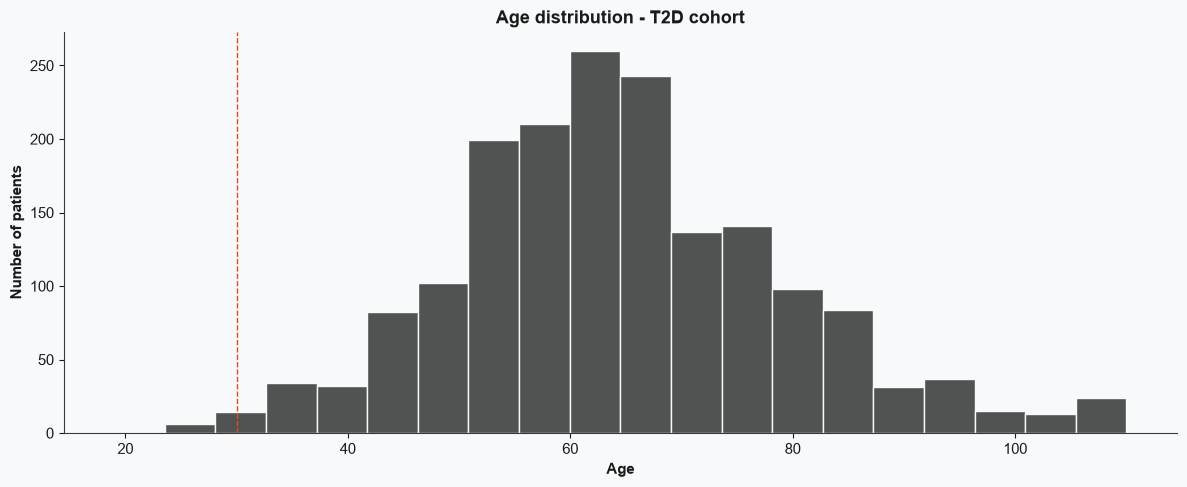

In [14]:
fig, ax = plt.subplots()
sns.histplot(cohort["AGE"], bins=20, color=COLOR_DARK, edgecolor=COLOR_BG, ax=ax)
ax.axvline(30, color=COLOR_ACCENT, linestyle="--", linewidth=1)
ax.set_xlabel("Age")
ax.set_ylabel("Number of patients")
ax.set_title("Age distribution - T2D cohort")
plt.tight_layout()
plt.show()

Decision: include all 1,763 patients in the main analysis, without special consideration for age. This is a result in itself that should be documented in the protocol: the planned exploratory step has been carried out, and it has led to the conclusion that, in this synthetic population, no relevant early-onset subgroup emerges (which is also plausible considering that Synthea generates realistic prevalences, and juvenile diabetes is indeed rare). We will add this to the protocol, along with the creatinine note, in a single update session.